## **Tutorial: Generating an Airy Sea Profile with WaveSpec.jl**

This tutorial demonstrates how to use the WaveSpec package to simulate a primary sea state using Airy Wave Theory (Linear Wave Theory). We will construct a synthetic sea surface by defining two independent distributions modeling the sea spectral density and the angular spreading. Both distributions are discretized it into components, and added in order to generate the sea profiles according to Airy Wave theory.

In [4]:
using WaveSpec
using Distributions
using Plots

#### **Generate Angular spreading model**



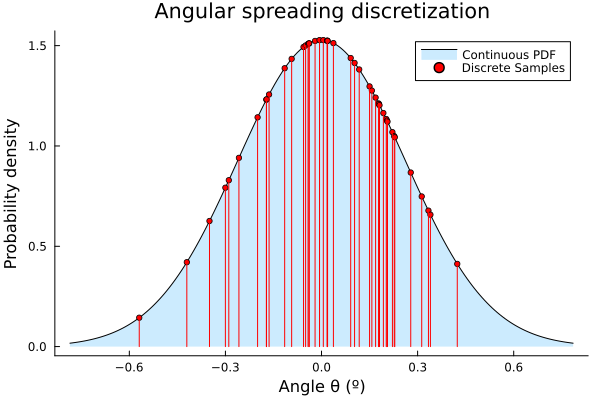

In [ ]:
# Generate angular spreading structure
using WaveSpec.AngularSpreading

μ = 0.0
σ = 15.0 * (π/180)  
θmin = -45.0 * (π/180)
θmax = 45.0 * (π/180)
nθ = 45
AngSprea = DiscreteAngularSpreading(:normal, μ, σ, θmin, θmax, nθ) 

plot(AngSprea)

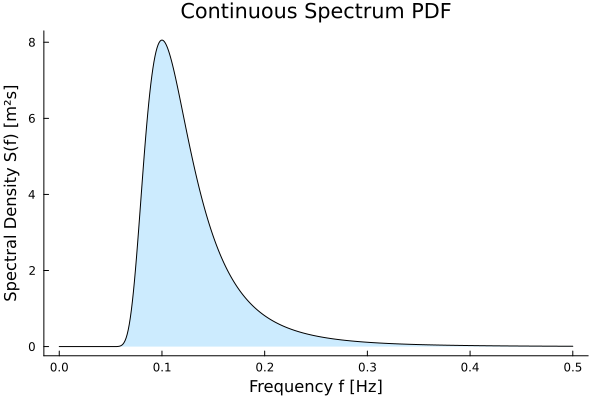

In [22]:
using WaveSpec.ContinuousSpectrums

# Generate continuous spectrum model 
Hs = 3.0
Tp = 10.0
Cspec = JONSWAP(Hs, Tp)

plot(Cspec)

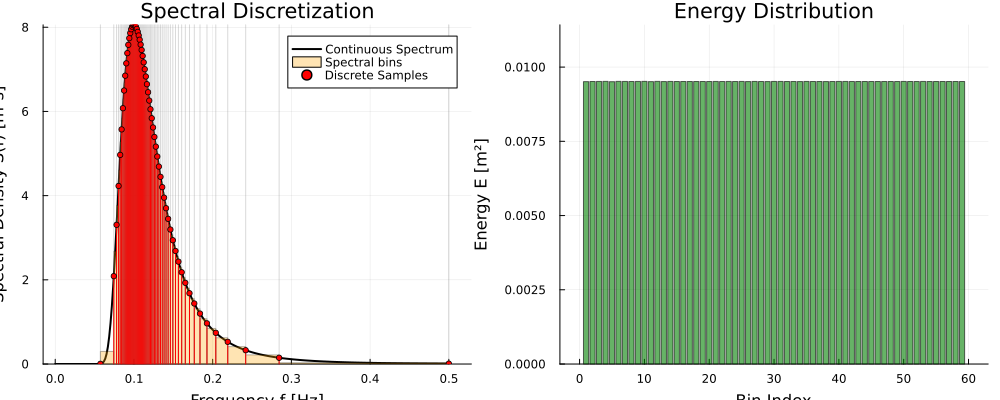

In [ ]:
using WaveSpec.SpectralSampling
using WaveSpec.SpectralSpreading

# Generate discrete spectrum 
nf = 60
Dspec = DiscreteSpectralSpreading(Cspec, UniformSampling(), get_fmin(Cspec), get_fmax(Cspec), nf; 
                        domain=SpectralSampling.Energy, mess=false)

plot(Dspec)

In [24]:
using WaveSpec.AiryWaves

# Generate Airy sea state
h = 2.0
airysea = AiryState(Dspec, AngSprea, h)

AiryState(DiscreteSpectrum(JONSWAP{Float64}(3.0, 10.0, 0.1, 1.0, 1.0000078065322076, 0.6283185307179586, 0.07, 0.09), UniformSampling(), EnergyDomain(), 1.0e-5, 0.5, 60, 59, 1.0164844001817674), SpreadingModel{Normal{Float64}, Float64}(WaveSpec.Truncation.TruncatedModel{Normal{Float64}, Float64}(
dist: Normal{Float64}(μ=0.0, σ=0.2617993877991494)
a: -0.7853981633974483
b: 0.7853981633974483
Z: 0.9973002039367398
cdf_a: 0.001349898031630093
cdf_b: 0.9986501019683699
)
, 45, 6249504864046810011), 59, 44, [0.41402337530439914, 0.4786092295995262, 0.49768227810866855, 0.5121146183170031, 0.5242769923568005, 0.5350706678082363, 0.5449525867459093, 0.5541806335060269, 0.5629277049364667, 0.5713140771634447  …  1.0239016545408772, 1.0550658348535573, 1.0908711451745614, 1.1328446667713115, 1.1833549980164522, 1.2463773515573051, 1.3293294246717542, 1.4485638941783743, 1.653676915208601, 2.4644147478965786], [0.09403483899207367, 0.10891883395863589, 0.11333176162157015, 0.11667666501359931, 0

In [ ]:
# Define spatial grid: 100m x 100m
nx, ny = 100, 100
x_coords = range(-50.0, 50.0, length=nx)
y_coords = range(-50.0, 50.0, length=ny)

# Time and vertical position (surface)
t_val = [0.0]
z_val = [0.0]

profiles = generate_sea(airysea, x_coords, y_coords, z_val, t_val, vars=[:η])

(η = [-0.1910122511143663 -0.18086312396207557 … -0.5458061541215137 -0.5247370721966058; -0.30976780198345233 -0.31312428996063846 … -0.6684688758184771 -0.6514968103684353; … ; 0.2219865054355335 0.17810396414213533 … 0.33111646826553376 0.340812355793667; 0.15054063911950866 0.1007656964930845 … 0.3656593480064635 0.38349159854210085;;;;],)

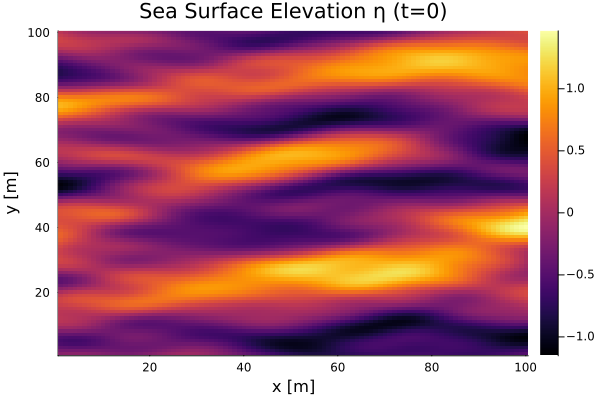

In [26]:
# Plotting
p1 = heatmap(profiles.η[:,:,1,1], 
             colorbar=true, 
             title="Sea Surface Elevation η (t=0)",
             xlabel="x [m]", ylabel="y [m]")